In [ ]:
!pip install kagglehub -q

import kagglehub

path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")
print("Path to dataset files:", path)

100%|██████████| 9.76G/9.76G [01:36<00:00, 108MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alessandrasala79/ai-vs-human-generated-dataset/versions/4


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation, BatchNormalization


In [ ]:
train_df = pd.read_csv(f'{path}/train.csv')
test_df = pd.read_csv(f'{path}/test.csv')
print("Train data columns:", train_df.columns.tolist())
print("Test data columns:", test_df.columns.tolist())
print("\nFirst few rows of train data:")
print(train_df.head(10))
print("\nFirst few rows of test data:")
print(test_df.head(10))

Train data columns: ['Unnamed: 0', 'file_name', 'label']
Test data columns: ['id']

First few rows of train data:
   Unnamed: 0                                        file_name  label
0           0  train_data/a6dcb93f596a43249135678dfcfc17ea.jpg      1
1           1  train_data/041be3153810433ab146bc97d5af505c.jpg      0
2           2  train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg      1
3           3  train_data/8542fe161d9147be8e835e50c0de39cd.jpg      0
4           4  train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg      1
5           5  train_data/25ea852f30594bc5915eb929682af429.jpg      0
6           6  train_data/e67085fb6d814cbabe08f978c738f3f7.jpg      1
7           7  train_data/041c36d9269146cdb88e7526e3b91651.jpg      0
8           8  train_data/4aea3b876247467c8d3713d4920148ab.jpg      1
9           9  train_data/09708379751e44d0bc908d8652d0db3e.jpg      0

First few rows of test data:
                                                  id
0  test_data_v2/1a2d9fd3e21b4266a


Sample image mode: RGB


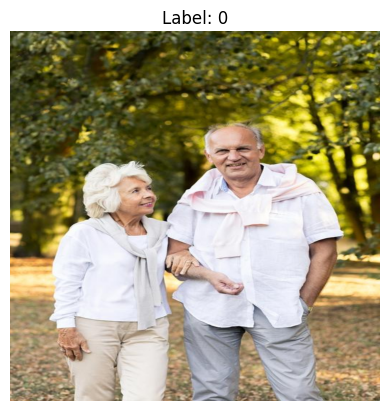

768 768


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Use the correct path where the dataset was downloaded
img_path = os.path.join(path, train_df.loc[1, "file_name"])

img = Image.open(img_path)
resized_img = img.resize((768, 768), Image.BICUBIC)
print(f"\nSample image mode: {img.mode}")
plt.imshow(resized_img)
plt.axis("off")
plt.title(f"Label: {train_df.loc[3, 'label']}")
plt.show()
w, h = resized_img.size
print(w,h)

**New Code**

Using Colab cache for faster access to the 'ai-vs-human-generated-dataset' dataset.
Path to dataset files: /kaggle/input/ai-vs-human-generated-dataset
Train data columns: ['Unnamed: 0', 'file_name', 'label']
   Unnamed: 0                                        file_name  label
0           0  train_data/a6dcb93f596a43249135678dfcfc17ea.jpg      1
1           1  train_data/041be3153810433ab146bc97d5af505c.jpg      0
2           2  train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg      1
3           3  train_data/8542fe161d9147be8e835e50c0de39cd.jpg      0
4           4  train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg      1


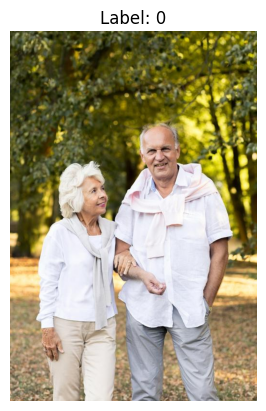

In [ ]:
!pip install kagglehub -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub

# 1. Download Dataset
path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")
print("Path to dataset files:", path)

# 2. Load DataFrames
train_df = pd.read_csv(os.path.join(path, 'train.csv'))
test_df = pd.read_csv(os.path.join(path, 'test.csv'))

print("Train data columns:", train_df.columns.tolist())
print(train_df.head())

# 3. Fix full file paths (kagglehub puts images relative to path)
train_df['full_path'] = train_df['file_name'].apply(lambda x: os.path.join(path, x))
test_df['full_path'] = test_df['id'].apply(lambda x: os.path.join(path, x)) # Corrected 'file_name' to 'id'

# 4. Corrected Sample Image Inspection (Index aligned)
sample_idx = 1
img_path = train_df.loc[sample_idx, "full_path"]
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.title(f"Label: {train_df.loc[sample_idx, 'label']}")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Global Specs
IMG_SIZE = (224, 224) # Standard ResNet input size
BATCH_SIZE = 32
SEED = 42

# Stratified Split (85% Train, 15% Validation)
train_data, val_data = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['label'],
    random_state=SEED
)

def parse_image(file_path, label=None):
    """Loads, decodes, resizes, and applies ResNet50 preprocessing."""
    image = tf.io.read_file(file_path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    # Scales pixel values to ResNet50 expected format
    image = keras.applications.resnet50.preprocess_input(image)

    if label is not None:
        return image, tf.cast(label, tf.float32)
    return image

def build_dataset(df, is_training=True):
    paths = df['full_path'].values
    labels = df['label'].values if 'label' in df.columns else None

    if labels is not None:
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = tf.data.Dataset.from_tensor_slices(paths)
        ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        ds = ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    else:
        ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = build_dataset(train_data, is_training=True)
val_ds = build_dataset(val_data, is_training=False)
test_ds = build_dataset(test_df, is_training=False)

In [ ]:
# Mild Data Augmentation (Keeps high-frequency AI artifacts intact)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
], name="data_augmentation")

# 1. Base Model (Pretrained ResNet50)
base_model = keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # Freeze backbone first

# 2. Complete Architecture
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs, name="ResNet50_Classifier")

# 3. Phase 1: Train Head Only
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks = [
    keras.callbacks.ModelCheckpoint("best_resnet50.keras", save_best_only=True, monitor="val_auc", mode="max"),
    keras.callbacks.EarlyStopping(monitor="val_auc", patience=3, mode="max", restore_best_weights=True)
]

print("--- Phase 1 Training ---")
model.fit(train_ds, validation_data=val_ds, epochs=3, callbacks=callbacks)

# 4. Phase 2: Fine-Tuning top 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), # Lower learning rate
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("--- Phase 2 Fine-Tuning ---")
model.fit(train_ds, validation_data=val_ds, epochs=8, callbacks=callbacks)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
--- Phase 1 Training ---
Epoch 1/3
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 13545s 6s/step - accuracy: 0.9193 - auc: 0.9756 - loss: 0.2004 - val_accuracy: 0.9501 - val_auc: 0.9886 - val_loss: 0.1415
Epoch 2/3
 492/2124 ━━━━━━━━━━━━━━━━━━━━ 2:26:23 5s/step - accuracy: 0.9297 - auc: 0.9801 - loss: 0.1822

In [ ]:
# Load top-performing model checkpoint
best_model = keras.models.load_model("best_resnet50.keras")

# Generate predicted probabilities on the test set
raw_preds = best_model.predict(test_ds)

# Convert to 0 (Human) or 1 (AI)
test_df['label'] = (raw_preds > 0.5).astype(int)

# Create submission
submission = test_df[['file_name', 'label']] # Ensure columns match Kaggle submission format
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv successfully!")
print(submission.head())